In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/mouna_engineered.csv')
scaler      = joblib.load('../data/models/scaler.pkl')
feature_cols = joblib.load('../data/models/feature_cols.pkl')
ensemble    = joblib.load('../data/models/mouna_ensemble.pkl')

# use logistic regression for SHAP (most interpretable)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df[feature_cols].values
y = df['high_risk'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_sm)

print("Model and data loaded successfully")
print(f"Test samples: {len(X_test_scaled)}")

Model and data loaded successfully
Test samples: 400


In [2]:
# SHAP explainer for logistic regression
explainer = shap.LinearExplainer(lr, X_train_scaled,
                                  feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test_scaled)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Features: {len(feature_cols)}")

# global mean absolute SHAP
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'feature': feature_cols,
    'mean_shap': mean_shap
}).sort_values('mean_shap', ascending=False)

print("\nTop 15 features by SHAP importance:")
print("="*45)
for _, row in shap_df.head(15).iterrows():
    bar = '█' * int(row['mean_shap'] * 500)
    print(f"  {row['feature']:<28} {row['mean_shap']:.4f}  {bar}")

SHAP values shape: (400, 30)
Features: 30

Top 15 features by SHAP importance:
  age                          2.0466  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

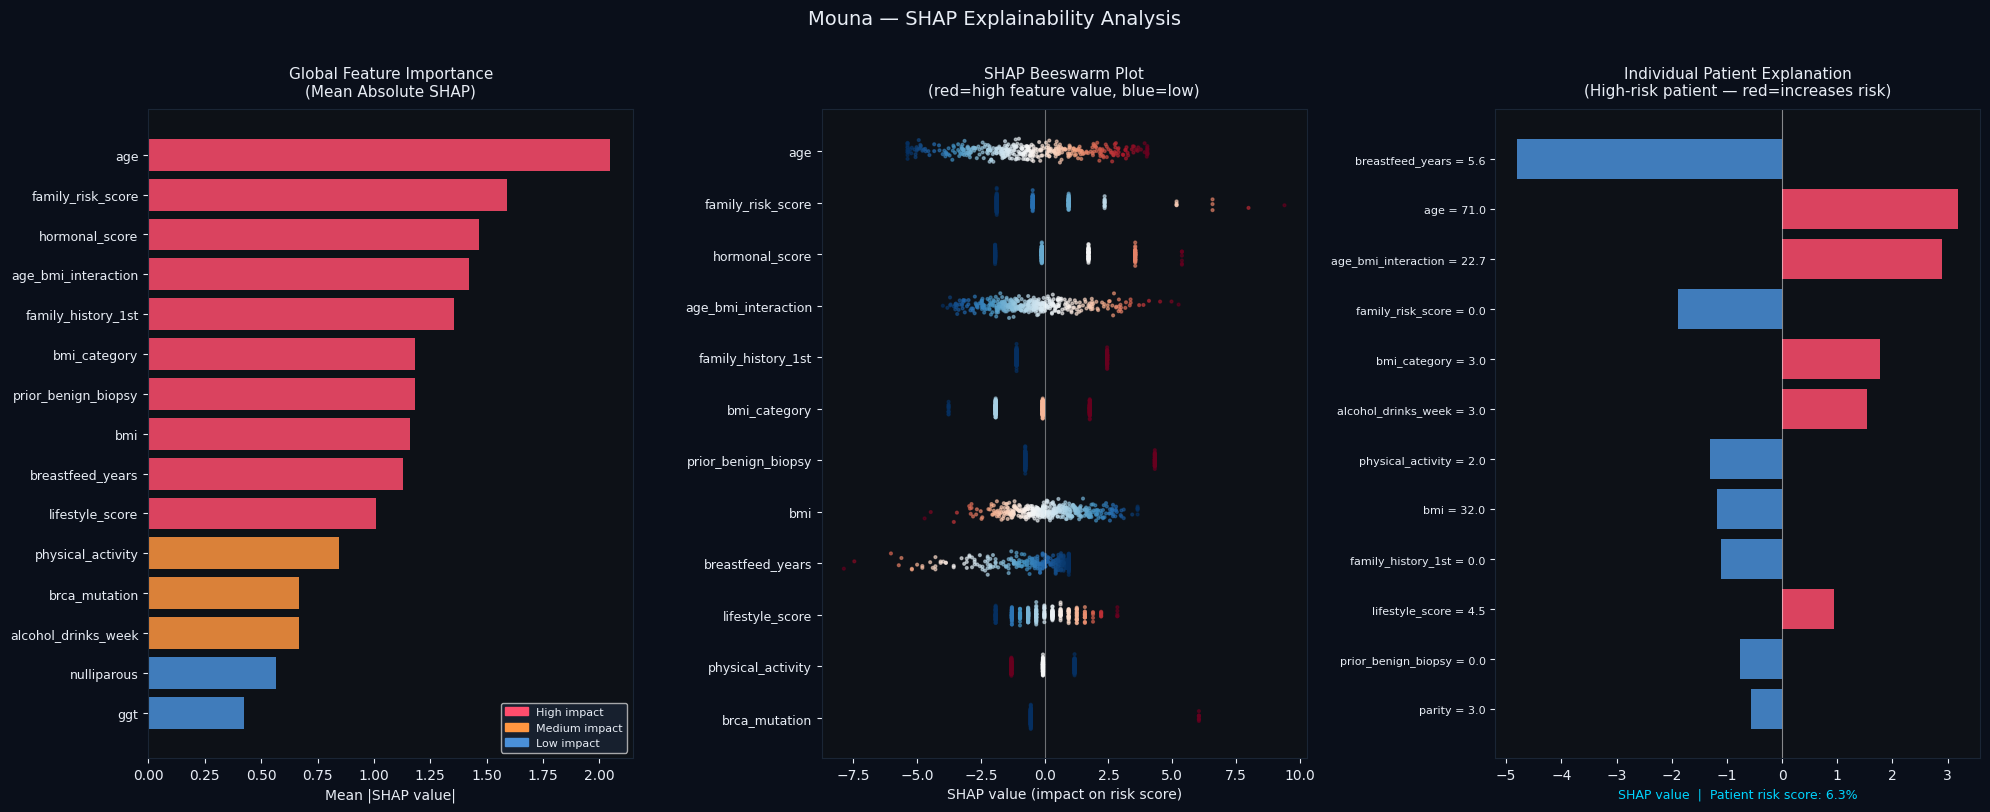

Saved to outputs/shap_analysis.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.patch.set_facecolor('#0a0f1a')

# ── Plot 1: Global SHAP bar chart (top 15) ────────────────
ax = axes[0]
ax.set_facecolor('#0d1117')

top15 = shap_df.head(15)
bar_colors = ['#ff4d6d' if v > 1.0 else
              '#ff9640' if v > 0.6 else
              '#4A90D9' for v in top15['mean_shap']]

ax.barh(range(len(top15)), top15['mean_shap'],
        color=bar_colors, alpha=0.85, edgecolor='none')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['feature'], fontsize=9, color='#e8edf5')
ax.set_xlabel('Mean |SHAP value|', color='#e8edf5')
ax.set_title('Global Feature Importance\n(Mean Absolute SHAP)',
             color='#e8edf5', fontsize=11, pad=10)
ax.tick_params(colors='#e8edf5')
ax.invert_yaxis()
for s in ax.spines.values(): s.set_edgecolor('#1a2535')

from matplotlib.patches import Patch
legend = [Patch(color='#ff4d6d', label='High impact'),
          Patch(color='#ff9640', label='Medium impact'),
          Patch(color='#4A90D9', label='Low impact')]
ax.legend(handles=legend, facecolor='#1a2535',
          labelcolor='#e8edf5', fontsize=8)

# ── Plot 2: SHAP beeswarm (top 12 features) ───────────────
ax2 = axes[1]
ax2.set_facecolor('#0d1117')

top12_features = shap_df.head(12)['feature'].tolist()
top12_idx = [feature_cols.index(f) for f in top12_features]
shap_top = shap_values[:, top12_idx]
X_test_top = X_test_scaled[:, top12_idx]

for i, feat in enumerate(top12_features):
    feat_vals = X_test_top[:, i]
    shap_vals = shap_top[:, i]

    # normalize feature values for color
    norm = (feat_vals - feat_vals.min()) / (feat_vals.max() - feat_vals.min() + 1e-8)
    colors_scatter = plt.cm.RdBu_r(norm)

    # add jitter
    y_jitter = np.random.normal(i, 0.08, len(shap_vals))

    ax2.scatter(shap_vals, y_jitter,
                c=colors_scatter, s=4, alpha=0.6)

ax2.set_yticks(range(len(top12_features)))
ax2.set_yticklabels(top12_features, fontsize=9, color='#e8edf5')
ax2.axvline(0, color='white', linewidth=0.8, alpha=0.4)
ax2.set_xlabel('SHAP value (impact on risk score)',
               color='#e8edf5')
ax2.set_title('SHAP Beeswarm Plot\n(red=high feature value, blue=low)',
              color='#e8edf5', fontsize=11, pad=10)
ax2.tick_params(colors='#e8edf5')
ax2.invert_yaxis()
for s in ax2.spines.values(): s.set_edgecolor('#1a2535')

# ── Plot 3: Individual patient explanation ────────────────
ax3 = axes[2]
ax3.set_facecolor('#0d1117')

# pick a high-risk patient
high_risk_idx = np.where(y_test == 1)[0]
patient_idx = high_risk_idx[0]

patient_shap = shap_values[patient_idx]
patient_features = X_test[patient_idx]

# get top contributing features for this patient
contrib_df = pd.DataFrame({
    'feature': feature_cols,
    'shap':    patient_shap,
    'value':   patient_features
}).reindex(pd.Series(np.abs(patient_shap)).sort_values(ascending=False).index)
contrib_df = contrib_df.head(12)

colors_contrib = ['#ff4d6d' if v > 0 else '#4A90D9'
                  for v in contrib_df['shap']]
ax3.barh(range(len(contrib_df)), contrib_df['shap'],
         color=colors_contrib, alpha=0.85, edgecolor='none')
ax3.set_yticks(range(len(contrib_df)))
ax3.set_yticklabels([
    f"{r['feature']} = {r['value']:.1f}"
    for _, r in contrib_df.iterrows()
], fontsize=8, color='#e8edf5')
ax3.axvline(0, color='white', linewidth=0.8, alpha=0.5)
ax3.set_xlabel('SHAP value', color='#e8edf5')
ax3.set_title('Individual Patient Explanation\n(High-risk patient — red=increases risk)',
              color='#e8edf5', fontsize=11, pad=10)
ax3.tick_params(colors='#e8edf5')
ax3.invert_yaxis()
for s in ax3.spines.values(): s.set_edgecolor('#1a2535')

# patient risk score
prob = lr.predict_proba(X_test_scaled[patient_idx:patient_idx+1])[0,1]
ax3.set_xlabel(f'SHAP value  |  Patient risk score: {prob*100:.1f}%',
               color='#00d4ff', fontsize=9)

plt.suptitle('Mouna — SHAP Explainability Analysis',
             color='#e8edf5', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/shap_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0f1a')
plt.show()
print("Saved to outputs/shap_analysis.png")